In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import math

device = 'cpu'

def t(x):
    return torch.as_tensor(x, dtype=torch.get_default_dtype()).to(device)

print("Device:", device)

Device: cpu


## 1. GMM "difficile" + score exact

In [2]:

means_list = [
    [-15.0,  0.0],  
    [ 10.0,  0.0],  
    [ 0.0,  15.0],   
    [ 0.0, -6.0],   
    [ 0.0,  0.0],   
    [ 8.0,  8.0],   
    [8.0, -8.0],   
]

mean = torch.stack([t(m) for m in means_list], dim=0).to(device)  # (K,2)
K = mean.size(0)

cov_list = [
    2.4 * torch.eye(2, device=device),   # k=0
    0.4 * torch.eye(2, device=device),   # k=1
    0.7 * torch.eye(2, device=device),   # k=2
    0.7 * torch.eye(2, device=device),   # k=3
    3.0 * torch.eye(2, device=device),   # k=4 (gros mode très large)
    0.05 * torch.eye(2, device=device),  # k=5 (ultra-sharp)
    0.05 * torch.eye(2, device=device),  # k=6 (ultra-sharp)
]

cov = torch.stack(cov_list, dim=0).to(device)  # (K,2,2)

weights_list = [0.02, 0.16, 0.12, 0.11, 0.45, 0.02, 0.12]  
w = t(weights_list)
w = w / w.sum()  # just in case
weights = dist.Categorical(w)

gaussians = dist.MultivariateNormal(mean, cov)
target_dist = dist.MixtureSameFamily(weights, gaussians)

print("K =", K)
print("Means:\n", mean)
print("Weights:\n", w)

K = 7
Means:
 tensor([[-15.,   0.],
        [ 10.,   0.],
        [  0.,  15.],
        [  0.,  -6.],
        [  0.,   0.],
        [  8.,   8.],
        [  8.,  -8.]])
Weights:
 tensor([0.0200, 0.1600, 0.1200, 0.1100, 0.4500, 0.0200, 0.1200])


In [3]:
def score(distrib, x):
    """
    Score exact ∇_x log p(x) via autograd.
    x: (N,2)
    """
    x = x.clone().detach().requires_grad_(True)
    lp = distrib.log_prob(x)
    s, = torch.autograd.grad(lp.sum(), x)
    return s

true_clean_score = lambda x: score(target_dist, x)

## 2. Distributions bruitées p_σ et scores exacts p_σ

In [4]:
def construct_GMM_noised_distribution(noise_list, loc, cov, weights):
    d = loc.size(-1)
    noised = []
    for sigma in noise_list:
        g = dist.MultivariateNormal(
            loc,
            cov + torch.eye(d, device=device) * sigma**2
        )
        noised.append(dist.MixtureSameFamily(weights, g))
    return noised

SIGMA_MIN = 0.1
SIGMA_MAX = 20.0   
N_SIGMAS  = 10

sigmas = torch.logspace(
    torch.log10(t(SIGMA_MIN)),
    torch.log10(t(SIGMA_MAX)),
    N_SIGMAS,
    device=device
).flip(0)

print("Sigmas (du gros bruit au petit):", sigmas)

true_noised_dist = construct_GMM_noised_distribution(
    sigmas, mean, cov, weights
)

true_noised_scores = [
    (lambda d: (lambda x: score(d, x)))(d)
    for d in true_noised_dist
]

Sigmas (du gros bruit au petit): tensor([20.0000, 11.1009,  6.1616,  3.4200,  1.8982,  1.0536,  0.5848,  0.3246,
         0.1802,  0.1000])


## 3. Norme du score *théorique* (true) pour calibrer SNR

In [5]:
def estimate_score_norm_true(distrib, score_fn, n_samples=30000):
    """
    E_{X~distrib}[||score_true(X)||²] via MC, mais avec le score exact (théorique).
    """
    x = distrib.sample((n_samples,)).to(device)
    s = score_fn(x)
    return (s**2).sum(dim=1).mean().item()

norm_clean_true = estimate_score_norm_true(target_dist, true_clean_score, n_samples=30000)
print("E[||score_clean||²] ≈", norm_clean_true)

norms_true_sigmas = []
for i in range(len(sigmas)):
    n_val = estimate_score_norm_true(true_noised_dist[i], true_noised_scores[i], n_samples=30000)
    norms_true_sigmas.append(n_val)
norms_true_sigmas = np.array(norms_true_sigmas, dtype=np.float64)
print("E[||score_σ||²] pour chaque σ:", norms_true_sigmas)

E[||score_clean||²] ≈ 7.338352203369141
E[||score_σ||²] pour chaque σ: [4.59398096e-03 1.27649726e-02 3.08955442e-02 8.11560377e-02
 3.02928925e-01 8.77626181e-01 1.80329013e+00 3.28561473e+00
 5.00459337e+00 6.28483772e+00]


## 4. Clustering et histogrammes

In [6]:
def assign_clusters(x, means):
    x = x.to(means.device)
    x_exp = x.unsqueeze(1)           # (N,1,2)
    m_exp = means.unsqueeze(0)       # (1,K,2)
    dist2 = ((x_exp - m_exp)**2).sum(dim=-1)   # (N,K)
    return dist2.argmin(dim=1)

def plot_cluster_hist_multi(samples_list, means, true_weights, labels, title):
    """
    Compare plusieurs ensembles de samples sur un même histogramme de proportions par cluster.

    samples_list : liste de tenseurs (N_i, 2)
    means        : (K,2)
    true_weights : (K,)
    labels       : liste de strings de même longueur que samples_list
    """
    assert len(samples_list) == len(labels), "samples_list et labels doivent avoir la même longueur"

    means_cpu = means.detach().cpu()
    true_w    = true_weights.detach().cpu().numpy()
    K         = means_cpu.size(0)

    # x = indices des composantes k=0,...,K-1
    idx = np.arange(K)

    # largeur d'une barre
    n_models = len(samples_list)
    width = 0.8 / (n_models + 1)  # 0.8 = largeur totale réservée au centre

    plt.figure(figsize=(8, 4))

    # Barres des poids vrais (centrées)
    plt.bar(
        idx - 0.5*width*(n_models),  # léger décalage vers la gauche
        true_w,
        width,
        label="poids théoriques"
    )

    # Pour chaque ensemble de samples : assignation + proportions empiriques
    for i, (samples, lab) in enumerate(zip(samples_list, labels)):
        samples_cpu = samples.detach().cpu()
        clusters = assign_clusters(samples_cpu, means_cpu)
        counts = torch.bincount(clusters, minlength=K).float()
        emp = (counts / counts.sum()).numpy()

        # Décalage horizontal pour cet ensemble
        offset = (i + 1) * width  # +1 pour être à droite des poids vrais
        plt.bar(
            idx - 0.5*width*(n_models) + offset,
            emp,
            width,
            label=lab
        )

    plt.xticks(idx, [f"k={i}" for i in range(K)])
    plt.ylim(0, 0.6)
    plt.ylabel("proportion")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5. Langevin simple avec score de p (un seul niveau de bruit)

In [7]:
def langevin_simple_true(
    target_dist,
    score_fn,
    prior_dist,
    SNR,
    norm_score_true,
    n_steps,
    n_chain
):
    D = 2
    tau = 2 * D * SNR / norm_score_true
    noise_std = math.sqrt(2 * tau)
    print(f"[Langevin simple] tau={tau:.3e}, noise_std={noise_std:.3e}")

    X = prior_dist.sample((n_chain,)).to(device)

    for k in range(n_steps):
        drift = score_fn(X)
        X = X + tau * drift + noise_std * torch.randn_like(X)

    return X

## 6. Annealed Langevin (ALD) avec scores exacts p_σ

In [8]:
def annealed_langevin_true(
    prior,
    true_noisy_scores,
    sigmas,
    SNR,
    norms_true_sigmas,
    T_per_level,
    n_chain
):
    D = 2
    X = prior.sample((n_chain,)).to(device)

    for i in range(len(sigmas)):
        tau_i = 2 * D * SNR / norms_true_sigmas[i]
        noise_std_i = math.sqrt(2 * tau_i)
        print(f"[ALD] niveau {i}, σ={float(sigmas[i]):.3g}, "
              f"tau={tau_i:.3e}, noise_std={noise_std_i:.3e}")

        for _ in range(T_per_level):
            drift = true_noisy_scores[i](X)
            X = X + tau_i * drift + noise_std_i * torch.randn_like(X)

    return X

## 7. Prior + hyperparamètres

In [17]:
ALD_prior_mean = [0.0, 0.0]
ALD_prior_cov_scalar = 10.0  # prior encore plus large pour bien voir comment ça se contracte
SNR = 0.1

prior_mean = t(ALD_prior_mean)
prior_cov  = ALD_prior_cov_scalar * torch.eye(2, device=device)
prior_dist = dist.MultivariateNormal(prior_mean, prior_cov)

device = mean.device  

# bornes du prior uniforme (à adapter si besoin)
LOW  = torch.tensor([-20.0, -20.0], device=device)
HIGH = torch.tensor([ 20.0,  20.0], device=device)

prior_uniform = torch.distributions.Uniform(low=LOW, high=HIGH)


N_CHAIN = 2000

ALD_T_PER_LEVEL = 30
L_simple_steps = ALD_T_PER_LEVEL * len(sigmas)

## 8. Run des deux algos

In [18]:
X_langevin = langevin_simple_true(
    target_dist=target_dist,
    score_fn=true_clean_score,
    prior_dist=prior_dist,
    SNR=SNR,
    norm_score_true=norm_clean_true,
    n_steps=L_simple_steps,
    n_chain=N_CHAIN
).detach().cpu()

X_ald = annealed_langevin_true(
    prior=prior_dist,
    true_noisy_scores=true_noised_scores,
    sigmas=sigmas,
    SNR=SNR,
    norms_true_sigmas=norms_true_sigmas,
    T_per_level=ALD_T_PER_LEVEL,
    n_chain=N_CHAIN
).detach().cpu()

X_true = target_dist.sample((N_CHAIN,)).cpu()

[Langevin simple] tau=5.451e-02, noise_std=3.302e-01
[ALD] niveau 0, σ=20, tau=8.707e+01, noise_std=1.320e+01
[ALD] niveau 1, σ=11.1, tau=3.134e+01, noise_std=7.917e+00
[ALD] niveau 2, σ=6.16, tau=1.295e+01, noise_std=5.089e+00
[ALD] niveau 3, σ=3.42, tau=4.929e+00, noise_std=3.140e+00
[ALD] niveau 4, σ=1.9, tau=1.320e+00, noise_std=1.625e+00
[ALD] niveau 5, σ=1.05, tau=4.558e-01, noise_std=9.548e-01
[ALD] niveau 6, σ=0.585, tau=2.218e-01, noise_std=6.661e-01
[ALD] niveau 7, σ=0.325, tau=1.217e-01, noise_std=4.934e-01
[ALD] niveau 8, σ=0.18, tau=7.993e-02, noise_std=3.998e-01
[ALD] niveau 9, σ=0.1, tau=6.365e-02, noise_std=3.568e-01


## 9. Scatter + histogrammes

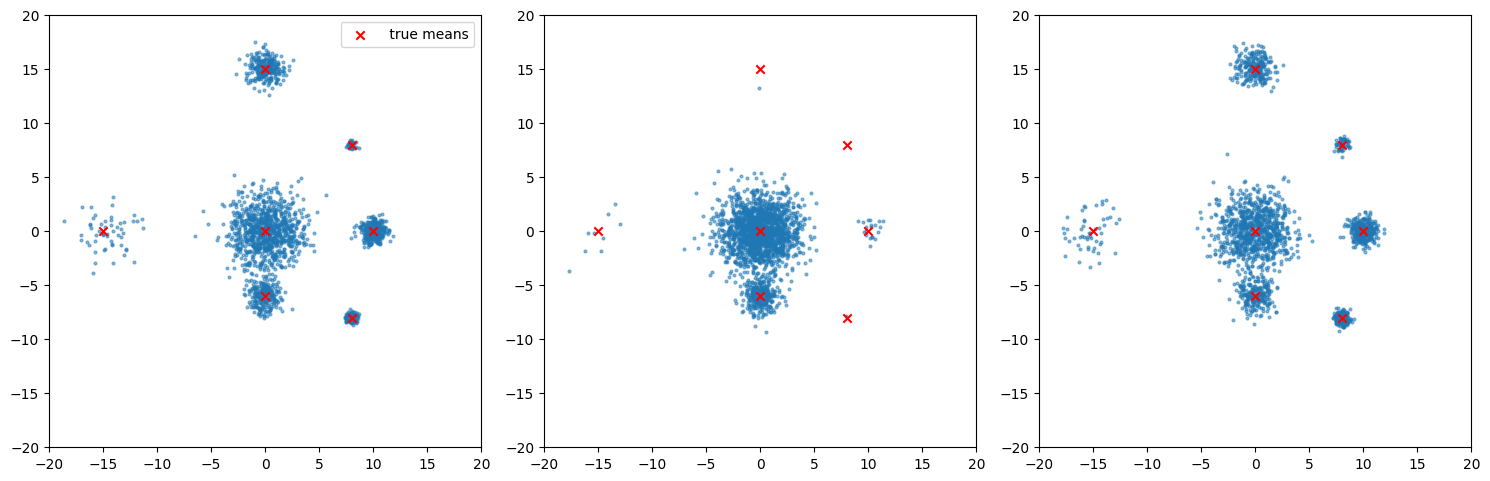

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(X_true[:,0], X_true[:,1], s=4, alpha=0.5)
plt.scatter(mean[:,0].cpu(), mean[:,1].cpu(), c='red', marker='x', label=" true means")
# plt.title("True distribution")
plt.xlim(-20,20); plt.ylim(-20,20)
plt.gca().set_aspect('equal')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(X_langevin[:,0], X_langevin[:,1], s=4, alpha=0.5)
plt.scatter(mean[:,0].cpu(), mean[:,1].cpu(), c='red', marker='x')
# plt.title("Langevin simple")
plt.xlim(-20,20); plt.ylim(-20,20)
plt.gca().set_aspect('equal')

plt.subplot(1,3,3)
plt.scatter(X_ald[:,0], X_ald[:,1], s=4, alpha=0.5)
plt.scatter(mean[:,0].cpu(), mean[:,1].cpu(), c='red', marker='x')
# plt.title("Annealed Langevin")
plt.xlim(-20,20); plt.ylim(-20,20)
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

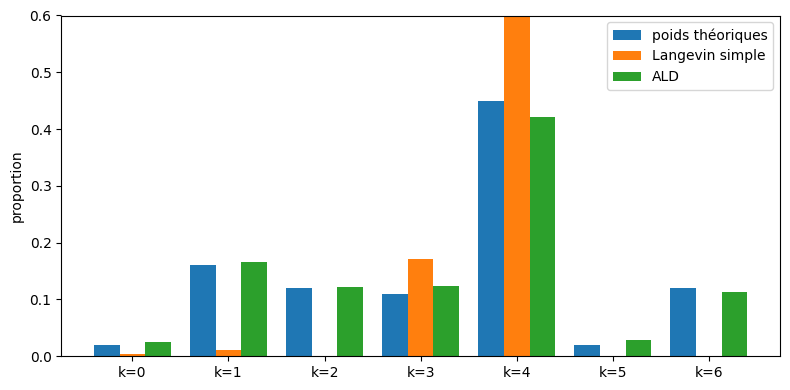

In [20]:
plot_cluster_hist_multi(
    samples_list=[X_langevin, X_ald],
    means=mean,
    true_weights=w,
    labels=["Langevin simple", "ALD"],
    title=""
)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def langevin_simple_true_with_evolution(
    target_dist,
    score_fn,
    prior_dist,
    SNR,
    norm_score_true,
    n_steps,
    n_chain,
    means=None,
    n_panels=12,
    xlim=(-20, 20),
    ylim=(-20, 20),
    figsize=None,
    figpath=None,
):
    """
    Même dynamique que `langevin_simple_true`, mais:
      - prend des snapshots de la chaîne à plusieurs itérations,
      - affiche l'évolution des samples sur une seule ligne de subplots.

    n_panels = nombre total de vues (début, fin + intermédiaires).
    """
    if figsize is None:
        figsize = (3 * n_panels, 3)  # 3 inches par subplot, à adapter

    D = 2
    tau = 2 * D * SNR / norm_score_true
    noise_std = math.sqrt(2 * tau)
    print(f"[Langevin simple (evolution)] tau={tau:.3e}, noise_std={noise_std:.3e}")

    # Init à partir du prior
    X = prior_dist.sample((n_chain,)).to(device)

    # Itérations où on prend un snapshot (0 = tout début, n_steps = fin)
    # ex: n_panels=12 -> 12 itérations espacées régulièrement entre 0 et n_steps
    snapshot_iters = np.linspace(0, n_steps, n_panels, dtype=int)
    snapshot_set = set(snapshot_iters.tolist())

    snapshots = []
    iters_recorded = []

    for k in range(n_steps + 1):
        # snapshot AVANT l'update pour bien voir le "vrai" état à k
        if k in snapshot_set:
            snapshots.append(X.detach().cpu())
            iters_recorded.append(k)

        if k == n_steps:
            break  # on s'arrête après avoir stocké le dernier état

        # une étape de Langevin
        drift = score_fn(X)
        X = X + tau * drift + noise_std * torch.randn_like(X)

    # --- Plot sur une seule ligne ---
    fig, axes = plt.subplots(1, len(snapshots), figsize=figsize)

    if len(snapshots) == 1:
        axes = [axes]  # pour la cohérence d'indexation

    means_cpu = None
    if means is not None:
        means_cpu = means.detach().cpu()

    for ax, X_snap, it in zip(axes, snapshots, iters_recorded):
        Xn = X_snap.numpy()
        ax.scatter(Xn[:, 0], Xn[:, 1], s=2, alpha=0.5)

        if means_cpu is not None:
            ax.scatter(
                means_cpu[:, 0],
                means_cpu[:, 1],
                c='red',
                marker='x',
                s=40
            )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect('equal')
        # ax.set_title(f"iter = {it}")

        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    if figpath is not None:
        plt.savefig(figpath, dpi=200)
    plt.show()

    # on renvoie quand même l'état final (comme l'original)
    return X


[Langevin simple (evolution)] tau=5.451e-02, noise_std=3.302e-01


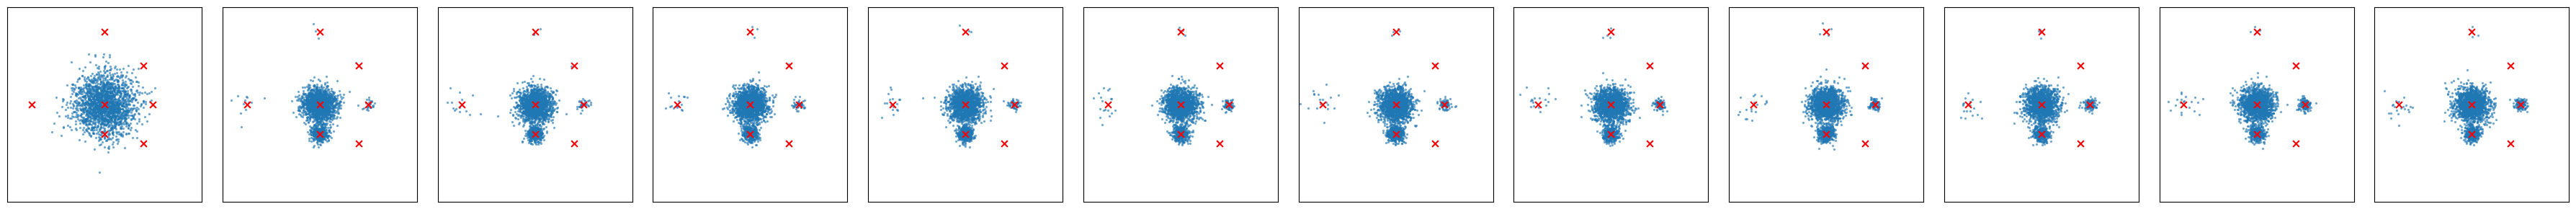

In [22]:
X_langevin_evol = langevin_simple_true_with_evolution(
    target_dist=target_dist,
    score_fn=true_clean_score,
    prior_dist=prior_dist,          # ou prior_gauss, comme tu veux
    SNR=0.1,
    norm_score_true=norm_clean_true,
    n_steps=L_simple_steps*100,
    n_chain=N_CHAIN,
    means=mean,                        # pour afficher les centres en rouge
    n_panels=12,                       # début + 10 milieux + fin
    xlim=(-20, 20),
    ylim=(-20, 20),
    figpath=None
)



In [26]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch

def annealed_langevin_true_with_evolution(
    prior,
    true_noisy_scores,
    sigmas,
    SNR,
    norms_true_sigmas,
    T_per_level,
    n_chain,
    means=None,
    xlim=(-20, 20),
    ylim=(-20, 20),
    figsize=None,
    figpath=None,
):
    """
    Same dynamics as `annealed_langevin_true`, but:
      - records snapshots at the beginning of each noise level,
      - records one final snapshot at the very end,
      - plots all snapshots on a single row of subplots.

    Returns:
        X : final samples (same as annealed_langevin_true)
    """
    D = 2
    X = prior.sample((n_chain,)).to(device)

    snapshots = []
    titles = []

    L = len(sigmas)

    for i in range(L):
        sigma_i = float(sigmas[i])

        # snapshot at the *beginning* of level i
        snapshots.append(X.detach().cpu())
        titles.append(f"start σ={sigma_i:.2g}")

        tau_i = 2 * D * SNR / norms_true_sigmas[i]
        noise_std_i = math.sqrt(2 * tau_i)
        print(f"[ALD] level {i}, σ={sigma_i:.3g}, "
              f"tau={tau_i:.3e}, noise_std={noise_std_i:.3e}")

        for _ in range(T_per_level):
            drift = true_noisy_scores[i](X)
            X = X + tau_i * drift + noise_std_i * torch.randn_like(X)

    # final snapshot after last level
    snapshots.append(X.detach().cpu())
    titles.append("final")

    # ---------- Plot on a single row ----------
    n_panels = len(snapshots)
    if figsize is None:
        # long and not too high
        figsize = (2.0 * n_panels, 2.0)

    fig, axes = plt.subplots(1, n_panels, figsize=figsize)
    if n_panels == 1:
        axes = [axes]

    means_cpu = None
    if means is not None:
        means_cpu = means.detach().cpu()

    for ax, X_snap, title in zip(axes, snapshots, titles):
        Xn = X_snap.numpy()
        ax.scatter(Xn[:, 0], Xn[:, 1], s=2, alpha=0.5)

        if means_cpu is not None:
            ax.scatter(
                means_cpu[:, 0],
                means_cpu[:, 1],
                c='red',
                marker='x',
                s=25
            )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        # ax.set_title(title, fontsize=8)

    plt.tight_layout()
    if figpath is not None:
        plt.savefig(figpath, dpi=200, bbox_inches='tight')
    plt.show()

    # return final samples like the original function
    return X


[ALD] level 0, σ=20, tau=8.707e+01, noise_std=1.320e+01
[ALD] level 1, σ=11.1, tau=3.134e+01, noise_std=7.917e+00
[ALD] level 2, σ=6.16, tau=1.295e+01, noise_std=5.089e+00
[ALD] level 3, σ=3.42, tau=4.929e+00, noise_std=3.140e+00
[ALD] level 4, σ=1.9, tau=1.320e+00, noise_std=1.625e+00
[ALD] level 5, σ=1.05, tau=4.558e-01, noise_std=9.548e-01
[ALD] level 6, σ=0.585, tau=2.218e-01, noise_std=6.661e-01
[ALD] level 7, σ=0.325, tau=1.217e-01, noise_std=4.934e-01
[ALD] level 8, σ=0.18, tau=7.993e-02, noise_std=3.998e-01
[ALD] level 9, σ=0.1, tau=6.365e-02, noise_std=3.568e-01


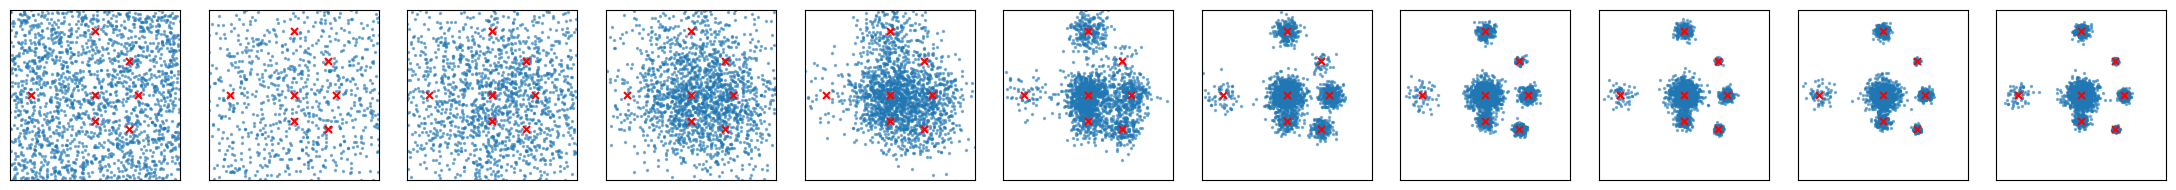

In [27]:
X_ald_final = annealed_langevin_true_with_evolution(
    prior=prior_uniform,                  # or prior_gauss
    true_noisy_scores=true_noised_scores,
    sigmas=sigmas,
    SNR=SNR,
    norms_true_sigmas=norms_true_sigmas,
    T_per_level=ALD_T_PER_LEVEL,
    n_chain=N_CHAIN,
    means=mean,
    xlim=(-20, 20),
    ylim=(-20, 20),
    figpath=None,
)
